In [27]:
import pandas as pd

# 1. Load the two datasets
df_trees = pd.read_csv('trees_within_radius.csv')
df_crown = pd.read_csv('crown_area_interpolated_final.csv')

# now make average crown area per species
df_crown 

,Unnamed: 0,OBJECTID,SITE_NAME,X,Y,EXTENT_EASTING_1,EXTENT_NORTHING_1,EXTENT_EASTING_2,EXTENT_NORTHING_2,LATIN_NAME,COMMON_NAME,FULL_COMMON_NAME,TREE_SPECIES,CROWN_WIDTH,CROWN_HEIGHT,DBH,PLANTING_SEASON,CROWN_AREA_MIDPOINT,CROWN_AREA_COMPLETE
0,0,26609351,Dovercourt Road To Muller Road Footpath,359956.40,176260.01,359956.40,176260.01,359956.40,176260.01,Fraxinus excelsior,Ash,Common ash,Fraxinus excelsior,14.0,15.0,NaN,Not Applicable,NaN,NaN
1,1,26609352,Dovercourt Road To Muller Road Footpath,359933.76,176296.56,359933.76,176296.56,359933.76,176296.56,Prunus - Species Unknown,Cherry,Unidentified cherry,Prunus - Species Unknown,NaN,NaN,NaN,Not Applicable,NaN,NaN
2,2,26609353,Eastville Roundabout M32 Junction 2,361186.30,175261.56,361186.30,175261.56,361186.30,175261.56,Metasequoia glyptostroboides,Dawn Redwood,Dawn redwood,Metasequoia glyptostroboides,1.0,4.0,0.07,Planting Season 08/09,10.00,10.00
3,3,26609354,Eastville Roundabout M32 Junction 2,361181.52,175236.67,361181.52,175236.67,361181.52,175236.67,Metasequoia glyptostroboides,Dawn Redwood,Dawn redwood,Metasequoia glyptostroboides,1.0,4.0,0.06,Planting Season 08/09,10.00,10.00
4,4,26609355,Eastville Roundabout M32 Junction 2,361164.98,175223.73,361164.98,175223.73,361164.98,175223.73,Metasequoia glyptostroboides,Dawn Redwood,Dawn redwood,Metasequoia glyptostroboides,NaN,NaN,NaN,Not Applicable,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55077,55077,26665022,Harptree Grove,357866.78,170853.97,357866.78,170853.97,357866.78,170853.97,Acer pseudoplatanus,Sycamore,Sycamore,Acer pseudoplatanus,6.0,8.0,0.32,Not Applicable,60.05,60.05
55078,55078,26665023,Harptree Grove,357867.89,170860.00,357867.89,170860.00,357867.89,170860.00,Acer pseudoplatanus,Sycamore,Sycamore,Acer pseudoplatanus,7.0,8.0,0.32,Not Applicable,60.05,60.05
55079,55079,26665024,Harptree Grove,357870.10,170864.07,357870.10,170864.07,357870.10,170864.07,Acer pseudoplatanus,Sycamore,Sycamore,Acer pseudoplatanus,7.0,8.0,0.35,Not Applicable,60.05,60.05
55080,55080,26665025,Harptree Grove,357873.44,170868.63,357873.44,170868.63,357873.44,170868.63,Acer pseudoplatanus,Sycamore,Sycamore,Acer pseudoplatanus,7.0,9.0,0.34,Not Applicable,60.05,60.05


In [28]:
df = df_crown

# 1. Define your evergreen set
evergreen_set = {
    "Bay", "Box", "Cabbage Palm", "Cedar", "Chusan Palm", "Conifer", "Cypress", "Douglas Fir", "Eleagnus",
    "Eucalyptus", "Feijoa", "Fir", "Firethorn", "Hiba", "Hemlock", "Holly", "Juniper", "Laurel", "Monkey Puzzle",
    "Pine", "Pittosporum", "Redwood", "Scots Pine", "Spruce", "Strawberry Tree", "Wedding Cake Tree", "Yew"
}

# (Assuming your dataframe is already loaded as 'df')

# --- INITIAL CHECK ---
missing_before = df['CROWN_AREA_COMPLETE'].isna().sum()
print(f"NaNs to fill: {missing_before}")

# --- PHASE 1: Species-Specific Averages ---
# Calculate the mean for each species and create a matching series
species_means = df.groupby('COMMON_NAME')['CROWN_AREA_COMPLETE'].transform('mean')

# Fill NaNs in the target column using the species_means series
df['CROWN_AREA_COMPLETE'] = df['CROWN_AREA_COMPLETE'].fillna(species_means)


# --- PHASE 2: Fallback to Evergreen/Deciduous Averages ---
# Create a temporary column to classify every tree as Evergreen or Deciduous
# We use .isin() for a fast, clean check against your set
df['Tree_Type'] = df['COMMON_NAME'].apply(lambda x: 'Evergreen' if x in evergreen_set else 'Deciduous')

# Calculate the mean for both types based on the CURRENT state of the data
type_means = df.groupby('Tree_Type')['CROWN_AREA_COMPLETE'].transform('mean')

# Fill any remaining NaNs (where a species had no numeric data at all) with the type mean
df['CROWN_AREA_COMPLETE'] = df['CROWN_AREA_COMPLETE'].fillna(type_means)


# --- CLEANUP AND VERIFY ---
# Drop the temporary Tree_Type column to keep your dataframe exactly as it was
df = df.drop(columns=['Tree_Type'])

missing_after = df['CROWN_AREA_COMPLETE'].isna().sum()
print(f"NaNs remaining: {missing_after} (Should be 0!)")

# Save your work
df.to_csv('imputed_crown_areas.csv', index=False)

NaNs to fill: 3152
NaNs remaining: 0 (Should be 0!)


Plot updated! Red dots are officially on top.


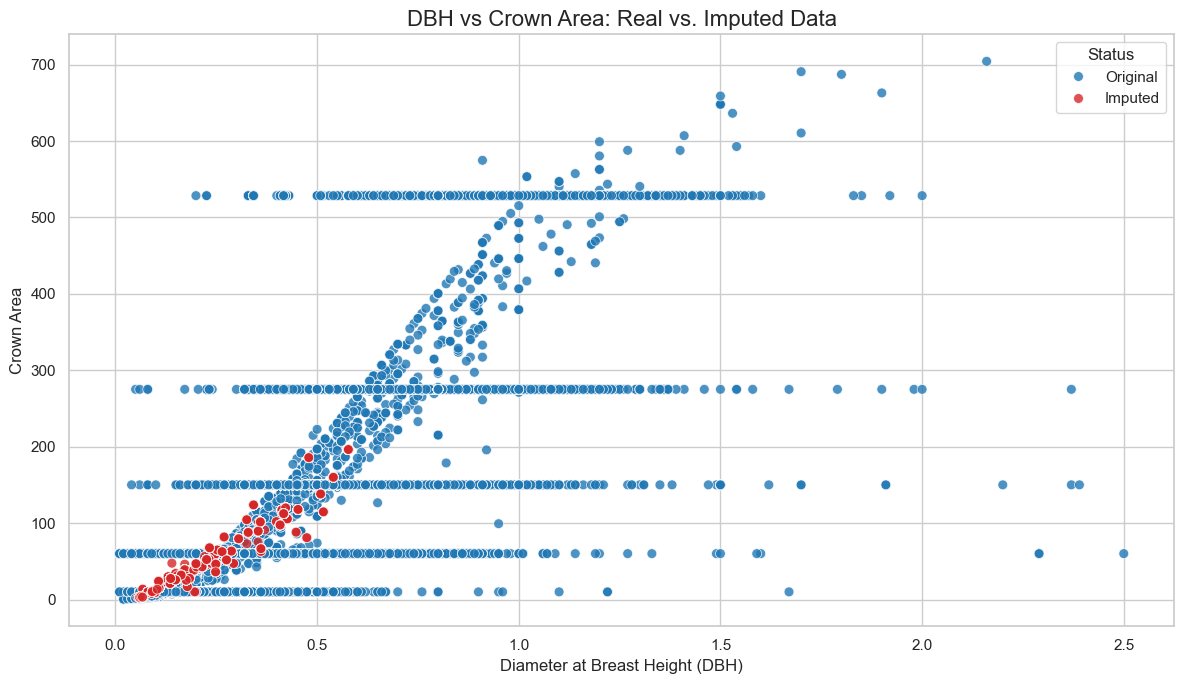

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset
df = pd.read_csv('crown_area_interpolated_final.csv')

# 2. Tag the data based on your primary target (Crown Area)
df['Data Source'] = np.where(df['CROWN_AREA_COMPLETE'].isna(), 'Imputed', 'Original')

# Define your tree types for the fallbacks
evergreen_set = {
    "Bay", "Box", "Cabbage Palm", "Cedar", "Chusan Palm", "Conifer", "Cypress", "Douglas Fir", "Eleagnus",
    "Eucalyptus", "Feijoa", "Fir", "Firethorn", "Hiba", "Hemlock", "Holly", "Juniper", "Laurel", "Monkey Puzzle",
    "Pine", "Pittosporum", "Redwood", "Scots Pine", "Spruce", "Strawberry Tree", "Wedding Cake Tree", "Yew"
}
df['Tree_Type'] = df['COMMON_NAME'].apply(lambda x: 'Evergreen' if x in evergreen_set else 'Deciduous')

# --- 3. IMPUTE DBH (The Missing X-Coordinates) ---
species_mean_dbh = df.groupby('COMMON_NAME')['DBH'].transform('mean')
df['DBH'] = df['DBH'].fillna(species_mean_dbh)

type_mean_dbh = df.groupby('Tree_Type')['DBH'].transform('mean')
df['DBH'] = df['DBH'].fillna(type_mean_dbh)

# --- 4. IMPUTE CROWN AREA (The Missing Y-Coordinates) ---
species_mean_crown = df.groupby('COMMON_NAME')['CROWN_AREA_COMPLETE'].transform('mean')
df['CROWN_AREA_COMPLETE'] = df['CROWN_AREA_COMPLETE'].fillna(species_mean_crown)

type_mean_crown = df.groupby('Tree_Type')['CROWN_AREA_COMPLETE'].transform('mean')
df['CROWN_AREA_COMPLETE'] = df['CROWN_AREA_COMPLETE'].fillna(type_mean_crown)

# Cleanup
df = df.drop(columns=['Tree_Type'])

df.to_csv('imputed_check.csv')

# --- 5. SORT AND PLOT ---
# Sort descending so 'Original' comes first, and 'Imputed' is at the bottom
df = df.sort_values('Data Source', ascending=False)

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=df, 
    x='DBH', 
    y='CROWN_AREA_COMPLETE', 
    hue='Data Source', 
    hue_order=['Original', 'Imputed'], # Explicitly tells Seaborn: draw Blue first, then Red on top!
    palette={'Original': '#1f77b4', 'Imputed': '#d62728'}, 
    alpha=0.8, 
    s=50       
)

plt.title('DBH vs Crown Area: Real vs. Imputed Data', fontsize=16)
plt.xlabel('Diameter at Breast Height (DBH)', fontsize=12)
plt.ylabel('Crown Area', fontsize=12)

plt.legend(title='Status')
plt.tight_layout()

plt.savefig('DBH_vs_CrownArea_RedImputed_OnTop.png', dpi=300)
print("Plot updated! Red dots are officially on top.")

In [36]:
df

,Unnamed: 0,OBJECTID,SITE_NAME,X,Y,EXTENT_EASTING_1,EXTENT_NORTHING_1,EXTENT_EASTING_2,EXTENT_NORTHING_2,LATIN_NAME,...,FULL_COMMON_NAME,TREE_SPECIES,CROWN_WIDTH,CROWN_HEIGHT,DBH,PLANTING_SEASON,CROWN_AREA_MIDPOINT,CROWN_AREA_COMPLETE,Data Source,Tree_Type
0,0,26609351,Dovercourt Road To Muller Road Footpath,359956.40,176260.01,359956.40,176260.01,359956.40,176260.01,Fraxinus excelsior,...,Common ash,Fraxinus excelsior,14.0,15.0,NaN,Not Applicable,NaN,101.542257,Imputed,Deciduous
38088,38088,26647849,Begbrook Green Park,363097.93,177205.72,363097.93,177205.72,363097.93,177205.72,Mixed Species,...,NaN,Mixed Species,NaN,NaN,NaN,Not Applicable,NaN,79.503646,Imputed,Deciduous
50988,50988,26660896,Kings Weston Avenue,353029.59,177551.08,353029.59,177551.08,353029.59,177551.08,Acer campestre 'Will Cladwell',...,Field maple,Acer campestre 'Will Cladwell',NaN,NaN,NaN,Planting Season 21/22,NaN,42.571330,Imputed,Deciduous
50987,50987,26660895,Kings Weston Avenue,353265.88,177547.67,353265.88,177547.67,353265.88,177547.67,Acer campestre 'Will Cladwell',...,Field maple,Acer campestre 'Will Cladwell',NaN,NaN,NaN,Planting Season 21/22,NaN,42.571330,Imputed,Deciduous
31880,31880,26641610,Oldbury Court Estate,363489.54,176576.38,363489.54,176576.38,363489.54,176576.38,Tilia - Species Unknown,...,Unidentified lime,Tilia - Species Unknown,6.0,6.0,NaN,Not Applicable,NaN,112.419599,Imputed,Deciduous
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19047,19047,26628651,Cumberland Basin (South),356852.51,171971.44,356852.51,171971.44,356852.51,171971.44,Acer pseudoplatanus,...,Sycamore,Acer pseudoplatanus,6.0,14.0,0.49,Not Applicable,60.05,60.050000,Original,Deciduous
19048,19048,26628652,Cumberland Basin (South),356842.51,171969.54,356842.51,171969.54,356842.51,171969.54,Acer pseudoplatanus,...,Sycamore,Acer pseudoplatanus,6.0,14.0,0.41,Not Applicable,60.05,60.050000,Original,Deciduous
19049,19049,26628653,Cumberland Basin (South),356833.58,171973.70,356833.58,171973.70,356833.58,171973.70,Acer platanoides,...,Norway maple,Acer platanoides,5.0,10.0,0.38,Not Applicable,60.05,60.050000,Original,Deciduous
18970,18970,26628573,Cumberland Basin (South),356643.35,172122.73,356643.35,172122.73,356643.35,172122.73,Quercus robur,...,English oak,Quercus robur,4.0,4.0,0.15,Planting Season 10/11,NaN,12.126761,Original,Deciduous


In [ ]:

# 2. Extract the target Object IDs from the TREES dataset
target_ids = df_trees['OBJECTID'].unique()

# 3. Filter the CROWN dataset 
# This keeps all columns in df_crown (including your extra one), 
# but only for the rows where the ObjectID was in the trees dataset.
df_result = df_crown[df_crown['OBJECTID'].isin(target_ids)]

# 4. Save the result to a new Excel file
df_result.to_excel('crown_area_filtered_output.xlsx', index=False)

print(f"Success! {len(df_result)} rows matched and saved with all crown area columns.")

In [ ]:
# 2. Filter the dataframe for rows where the area is less than 0
# Make sure the column name string exactly matches your file (spaces, caps, etc.)
negative_areas = df_result[df_result['CROWN_AREA_COMPLETE'] < 0]

# 3. Count how many times each species (COMMON_NAME) appears in this filtered list
species_counts = negative_areas['COMMON_NAME'].value_counts()

# 4. Print the results to your console
print("Number of negative crown areas per species:")
print(species_counts)

# Optional: Save this quick summary to a new CSV file so you have a record of it
#species_counts.to_csv('negative_areas_by_species.csv', header=['Count of Negatives'])

Number of negative crown areas per species:
Series([], Name: count, dtype: int64)
